# LFW 03-01. Fallback-free open-set 평가 시각화

검증된 Step 1 CSV를 읽어 threshold 정책별 DIR·FPIR와 저장량의 관계를
읽기 전용으로 시각화합니다. 새 검색, fallback 또는 결과 파일 덮어쓰기는 하지 않습니다.


In [1]:
from __future__ import annotations

import json
import os
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display

MODE = "real"
DATA_FRACTION = 1.0
SEED = 42
MODEL_NAME = "arcface"
EXECUTE_STAGE = True


def find_project_root(start: Path) -> Path:
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "research").is_dir() and (candidate / "configs").is_dir():
            return candidate
    raise FileNotFoundError("C:/ronbun 프로젝트 루트를 찾지 못했습니다.")


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
os.chdir(PROJECT_ROOT)

from research.experiments.scope import ExperimentScope
from research.runtime import resolve_active_run
from research.runtime.hashing import sha256_file

EXPERIMENT_SCOPE = ExperimentScope(
    mode=MODE, data_fraction=DATA_FRACTION, seed=SEED
)
RUN_DIR = resolve_active_run(PROJECT_ROOT / "runs" / "lfw", allow_completed=True)
RUN_MANIFEST = json.loads(
    (RUN_DIR / "run_manifest.json").read_text(encoding="utf-8")
)
RUN_ID = str(RUN_MANIFEST["run_id"])
SCOPE_TAG = f"{MODE}_p{DATA_FRACTION:.4f}_s{SEED}_{MODEL_NAME}"
RESULT_DIR = (
    PROJECT_ROOT / "results" / "step1" / "lfw" / RUN_ID / SCOPE_TAG
)
RESULT_MANIFEST_PATH = RESULT_DIR / "result_manifest.json"


In [2]:
if not RESULT_MANIFEST_PATH.is_file():
    raise FileNotFoundError(RESULT_MANIFEST_PATH)
result_manifest = json.loads(
    RESULT_MANIFEST_PATH.read_text(encoding="utf-8")
)
if result_manifest.get("scope") != EXPERIMENT_SCOPE.as_dict():
    raise ValueError("visualization scope와 result scope가 다릅니다.")
for name, expected in result_manifest.get("files", {}).items():
    path = RESULT_DIR / name
    if not path.is_file() or sha256_file(path) != expected.get("sha256"):
        raise ValueError(f"result artifact verification failed: {name}")

summary = pd.read_csv(RESULT_DIR / "compression_summary.csv")
retrieval = pd.read_csv(RESULT_DIR / "retrieval_comparison.csv")
fallback = retrieval["origin_fallback_used"]
if not pd.api.types.is_bool_dtype(fallback):
    fallback = fallback.astype(str).str.strip().str.lower().map(
        {"true": True, "false": False}
    )
if fallback.isna().any() or fallback.astype(bool).any():
    raise RuntimeError("fallback-free visualization 입력에 origin fallback이 있습니다.")

display(summary)


,compression_family,compression_profile,threshold_policy,query_count,mated_count,non_mated_count,dir_rank1,fpir,agreement_with_origin,threshold_crossing_rate,sample_count,mean_angular_error_rad,p95_angular_error_rad,mean_reconstruction_mse,mean_cosine_to_origin,storage_bytes_per_embedding,codebook_bytes,codebook_bytes_source
0,pca,pca_128,frozen_origin,2164,476,1688,0.993697,0.003555,0.540203,0.001848,2414,0.778429,0.877787,0.000963,0.710726,512,0,not_applicable
1,pca,pca_128,recalibrated_compressed,2164,476,1688,0.993697,0.001185,0.540203,0.000000,2414,0.778429,0.877787,0.000963,0.710726,512,0,not_applicable
2,pca,pca_256,frozen_origin,2164,476,1688,0.993697,0.001185,0.765250,0.000000,2414,0.441858,0.533653,0.000361,0.902701,1024,0,not_applicable
3,pca,pca_256,recalibrated_compressed,2164,476,1688,0.993697,0.001185,0.765250,0.000000,2414,0.441858,0.533653,0.000361,0.902701,1024,0,not_applicable
4,pca,pca_32,frozen_origin,2164,476,1688,0.989496,0.676540,0.315157,0.527726,2414,1.166909,1.258301,0.001647,0.392363,128,0,not_applicable
5,pca,pca_32,recalibrated_compressed,2164,476,1688,0.962185,0.013626,0.315157,0.017560,2414,1.166909,1.258301,0.001647,0.392363,128,0,not_applicable
6,pca,pca_384,frozen_origin,2164,476,1688,0.993697,0.001185,0.938540,0.000000,2414,0.087501,0.113877,0.000015,0.996065,1536,0,not_applicable
7,pca,pca_384,recalibrated_compressed,2164,476,1688,0.993697,0.001185,0.938540,0.000000,2414,0.087501,0.113877,0.000015,0.996065,1536,0,not_applicable
8,pca,pca_64,frozen_origin,2164,476,1688,0.993697,0.090640,0.402033,0.069778,2414,1.003636,1.101441,0.001387,0.536289,256,0,not_applicable
9,pca,pca_64,recalibrated_compressed,2164,476,1688,0.993697,0.004147,0.402033,0.002311,2414,1.003636,1.101441,0.001387,0.536289,256,0,not_applicable


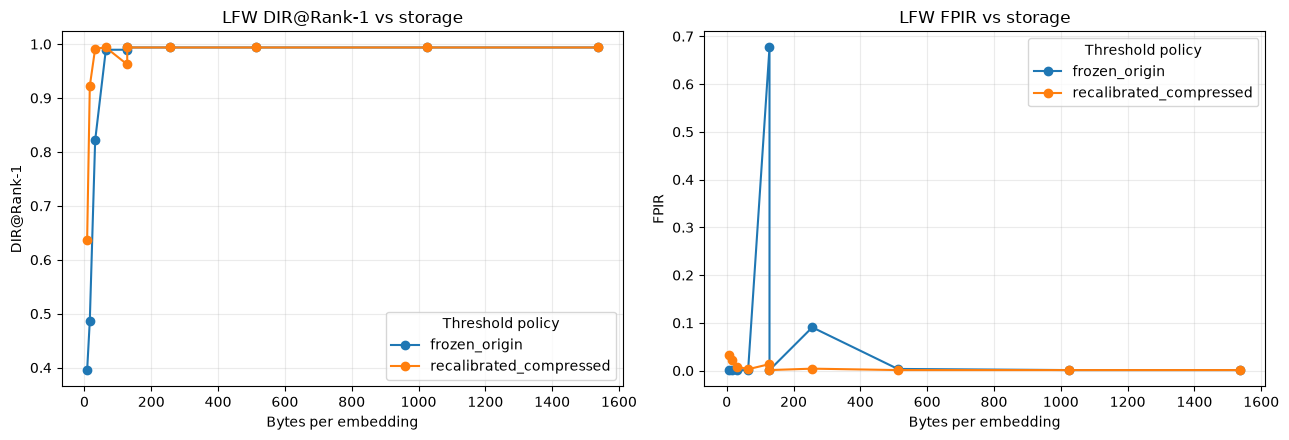

{'status': 'visualized_read_only',
 'run_id': '20260727-R002-9bf758ff',
 'profiles': 10,
 'threshold_policies': ['frozen_origin', 'recalibrated_compressed'],
 'origin_fallback_used': False}

In [3]:
result = {"status": "not_executed", "run_id": RUN_ID}
if EXECUTE_STAGE:
    figure_data = summary.sort_values(
        ["threshold_policy", "storage_bytes_per_embedding"]
    )
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
    for policy, group in figure_data.groupby("threshold_policy", sort=True):
        axes[0].plot(
            group["storage_bytes_per_embedding"],
            group["dir_rank1"],
            marker="o",
            label=str(policy),
        )
        axes[1].plot(
            group["storage_bytes_per_embedding"],
            group["fpir"],
            marker="o",
            label=str(policy),
        )
    axes[0].set(
        title="LFW DIR@Rank-1 vs storage",
        xlabel="Bytes per embedding",
        ylabel="DIR@Rank-1",
    )
    axes[1].set(
        title="LFW FPIR vs storage",
        xlabel="Bytes per embedding",
        ylabel="FPIR",
    )
    for axis in axes:
        axis.grid(alpha=0.25)
        axis.legend(title="Threshold policy")
    fig.tight_layout()
    display(fig)
    plt.close(fig)

    result = {
        "status": "visualized_read_only",
        "run_id": RUN_ID,
        "profiles": int(summary["compression_profile"].nunique()),
        "threshold_policies": sorted(
            summary["threshold_policy"].astype(str).unique().tolist()
        ),
        "origin_fallback_used": False,
    }
result


## 해석 경계

- 이 그림은 38개 detection-failure 제외 후 13,195개 embedding에 조건부입니다.
- `frozen_origin`과 `recalibrated_compressed`를 구분해 해석합니다.
- PQ codebook은 development 7,742개로 학습되어 Faiss 권장 표본보다 적습니다.
- origin exact fallback으로 compressed 결과를 대체하지 않았습니다.
